<a href="https://colab.research.google.com/github/SweetlinN/Movie_reviews_prediction-2026/blob/main/movies_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# problem statment : moviews reviews predictions

# 1. import libraries

In [1]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 2. Data Gathering

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Movie_Review.csv to Movie_Review.csv


In [3]:
df = pd.read_csv('Movie_Review.csv')

In [4]:
# first five rows of the dataset

In [5]:
df.head(5)

,text,sentiment
0,"My daughter liked it but I was aghast, that a ...",neg
1,I... No words. No words can describe this. I w...,neg
2,this film is basically a poor take on the old ...,neg
3,"This is a terrible movie, and I'm not even sur...",neg
4,First of all this movie is a piece of reality ...,pos


In [6]:
# last five rows of the dataset

In [7]:
df.tail()

,text,sentiment
995,"""Campfire Tales"" is basically made up of three...",pos
996,I just saw this film at the phoenix film festi...,pos
997,It's out of question that the real Anna Anders...,pos
998,Michelle Pfeiffer stars as a mob widow who see...,pos
999,This film tells the stories of several couples...,pos


# 3. (EDA)Exploratory data Analysis

In [8]:
df['sentiment'].value_counts()

,count
sentiment,
neg,500
pos,500


In [9]:
df.isnull().sum()

,0
text,0
sentiment,0


In [10]:
def clean_review(review):
  str = ' '.join(word for word in review.split() if word.lower() not in stopwords.words('english'))
  return str

In [11]:
df['text'] = df['text'].apply(clean_review)

In [12]:
# draw Wordcloud

In [13]:
from wordcloud import WordCloud

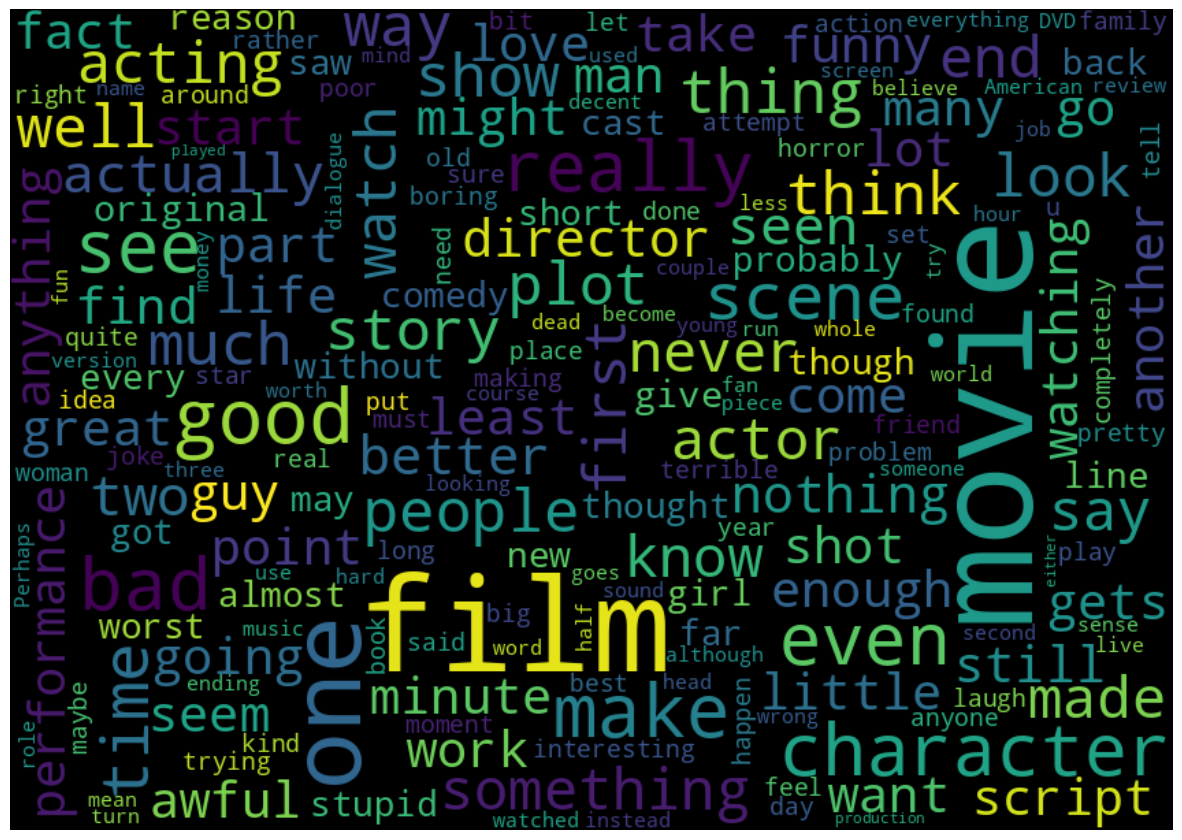

In [14]:
reviews = ' '.join(word for word in df['text'][df['sentiment'] == 'neg'].astype(str))
wordcloud = WordCloud(height = 600,width=850,max_font_size = 100)
plt.figure(figsize= (15,12))
plt.imshow(wordcloud.generate(reviews), interpolation='bilinear')
plt.axis('off')
plt.show()



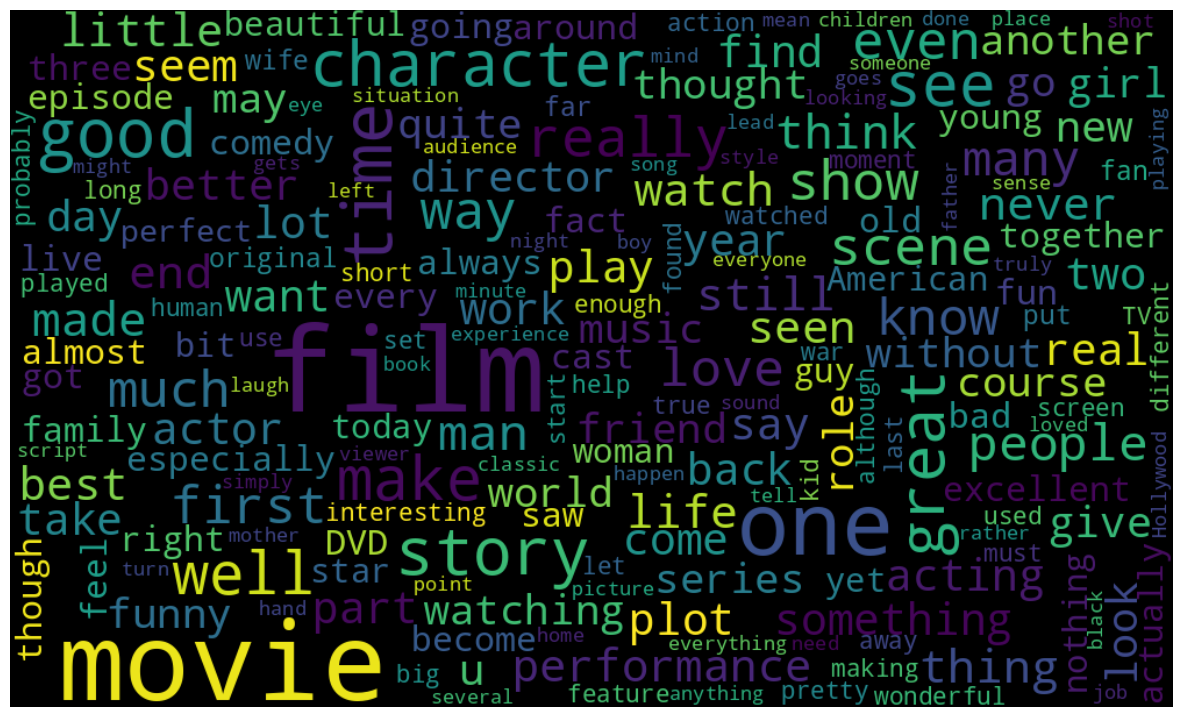

In [15]:
reviews = ' '.join(word for word in df['text'][df['sentiment'] == 'pos'].astype(str))
wordcloud = WordCloud(height = 600,width=1000,max_font_size = 100)
plt.figure(figsize= (15,12))
plt.imshow(wordcloud.generate(reviews), interpolation='bilinear')
plt.axis('off')
plt.show()



In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv = TfidfVectorizer(max_features=2500)


In [17]:
reviews = cv.fit_transform(df['text']).toarray()

In [18]:
df['sentiment'] = df['sentiment'].replace(['pos','neg'],[1,0])

/tmp/ipykernel_8296/432432424.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace(['pos','neg'],[1,0])


In [19]:
df['sentiment'].value_counts()

,count
sentiment,
0,500
1,500


In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
model = LogisticRegression()

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
reviews_train,reviews_test,sent_train,sent_test = train_test_split(reviews, df['sentiment'],test_size=0.2)


In [24]:
model.fit(reviews_train,sent_train)

LogisticRegression()

In [25]:

predict = model.predict(reviews_test)

In [26]:
predict

array([0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0])

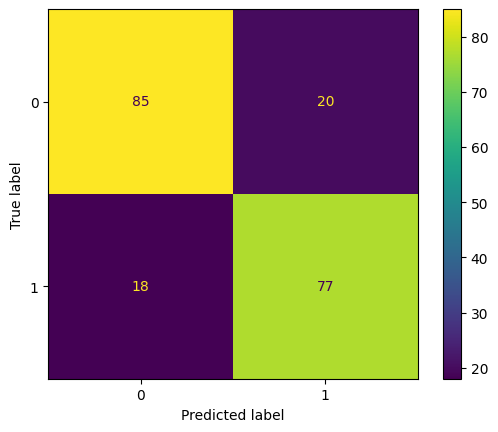

In [27]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(sent_test,predict,labels=model.classes_)
display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
display.plot()
plt.show()

In [31]:
# save the model

In [32]:
import joblib

In [35]:
joblib.dump(model,"Movie_reviews.pkl")

['Movie_reviews.pkl']

In [36]:
model = joblib.load("Movie_reviews.pkl")